# Form D / Regulation D Analysis

Canonical notebook for SEC EDGAR Form D structured data.

## Key facts
- Source: SEC EDGAR quarterly structured data TSV files — the same data WRDS parses into `wrdssec.wrds_vc_formd`
- Coverage: 2008 Q1 – 2024 Q4
- One row per filing in raw TSV (`SUBMISSIONTYPE = 'D'` for new filings, `'D/A'` for amendments)
- `FEDERALEXEMPTIONS_ITEMS_LIST`: comma-delimited exemption codes (e.g. `06b, 3C.1`)
- 2008–2013 zip files use `_0` revision suffix; 2014+ have no suffix
- No dedup needed after filtering to `SUBMISSIONTYPE = 'D'` and `DROP_DUPLICATES(ACCESSIONNUMBER)`


In [1]:
import urllib.request, zipfile, io, time, os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

## 1. Download Form D data from SEC EDGAR (2008–2024)

SEC publishes quarterly zip files containing four TSVs: FORMDSUBMISSION, OFFERING, ISSUERS, RECIPIENTS.
We join FORMDSUBMISSION + OFFERING on `ACCESSIONNUMBER` to get filing metadata and exemption codes.

Download takes ~5–10 min on first run; cached to parquet after that.

In [2]:
def download_formd_quarter(year: int, quarter: int) -> pd.DataFrame:
    """Download one quarter of Form D data from SEC EDGAR structured data.

    URL pattern: most pre-2014 quarters use _0 suffix; 2014+ use no suffix.
    Exceptions: 2008 Q1 and 2012 Q1 use plain URL (no _0).
    Strategy: try _0 first for pre-2014; fall back to plain if 404.
    """
    base = ('https://www.sec.gov/files/structureddata/data/'
            f'form-d-data-sets/{year}q{quarter}_d')
    headers = {'User-Agent': 'Edwin Hu ehu@law.virginia.edu'}

    candidates = []
    if year < 2014:
        candidates = [f'{base}_0.zip', f'{base}.zip']  # try _0 first, plain as fallback
    else:
        candidates = [f'{base}.zip']

    content = None
    for url in candidates:
        try:
            time.sleep(0.5)
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=60) as r:
                content = r.read()
            break
        except urllib.error.HTTPError as e:
            if e.code == 404:
                continue
            raise

    if content is None:
        raise FileNotFoundError(f'No file found for {year} Q{quarter}')

    zf = zipfile.ZipFile(io.BytesIO(content))
    fn_sub = [f for f in zf.namelist() if 'FORMDSUBMISSION' in f][0]
    fn_off = [f for f in zf.namelist() if 'OFFERING' in f][0]
    sub = pd.read_csv(zf.open(fn_sub), sep='\t', dtype=str)
    off = pd.read_csv(zf.open(fn_off), sep='\t', dtype=str)
    df = sub.merge(off, on='ACCESSIONNUMBER', how='left')
    df['_year'] = year
    df['_quarter'] = quarter
    return df

# Quick smoke test
sample = download_formd_quarter(2022, 1)
print(f'2022 Q1: {len(sample):,} rows')
print(f'Exemption samples: {sample["FEDERALEXEMPTIONS_ITEMS_LIST"].dropna().head(3).tolist()}')

2022 Q1: 18,558 rows
Exemption samples: ['06b, 3C, 3C.1, 3C.7', '06b', '06b']


In [3]:
CACHE_PATH = '/tmp/formd_all.parquet'

# Delete cache to re-download with fixed URL logic
if os.path.exists(CACHE_PATH):
    os.remove(CACHE_PATH)
    print('Deleted stale cache')

if not os.path.exists(CACHE_PATH):
    parts = []
    for year in range(2008, 2025):
        for q in range(1, 5):
            try:
                df = download_formd_quarter(year, q)
                parts.append(df)
                print(f'  {year} Q{q}: {len(df):,} rows')
                time.sleep(0.5)
            except Exception as e:
                print(f'  {year} Q{q}: skipped ({e})')
    raw = pd.concat(parts, ignore_index=True)
    raw.to_parquet(CACHE_PATH)
    print(f'\nCached {len(raw):,} total rows -> {CACHE_PATH}')
else:
    raw = pd.read_parquet(CACHE_PATH)
    print(f'Loaded from cache: {len(raw):,} rows')

print(f'Years: {sorted(raw["_year"].unique())}')
raw[['ACCESSIONNUMBER', 'SUBMISSIONTYPE', 'FILING_DATE',
     'FEDERALEXEMPTIONS_ITEMS_LIST', 'TOTALAMOUNTSOLD', '_year']].head()

Deleted stale cache


  2008 Q1: 1 rows


  2008 Q2: 1 rows


  2008 Q3: 31 rows


  2008 Q4: 409 rows


...

  2024 Q2: 13,699 rows


  2024 Q3: 13,222 rows


  2024 Q4: 13,611 rows



Cached 674,121 total rows -> /tmp/formd_all.parquet
Years: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,ACCESSIONNUMBER,SUBMISSIONTYPE,FILING_DATE,FEDERALEXEMPTIONS_ITEMS_LIST,TOTALAMOUNTSOLD,_year
0,0001477399-09-000001,D,2008-01-02 06:01:00,06,0,2008
1,0001192482-09-000126,D,2008-05-30 06:01:00,"06, 3C, 3C.7",2373500,2008
2,0001446406-08-000001,D,2008-09-30 17:24:23,06,525000,2008
3,0001446409-08-000001,D,2008-09-30 16:51:44,06,35000,2008
4,0001446405-08-000001,D,2008-09-30 16:33:23,06,2175000,2008


## 2. Parse exemption codes and build annual counts

`FEDERALEXEMPTIONS_ITEMS_LIST` is comma-delimited (e.g. `06b, 3C.1`). A filing can claim multiple codes.
We assign each filing one **primary** exemption using the priority order below.

Priority rationale: 506(c) > 506(b) > old 506 > 505 > 4(a)(2) > Investment Co. Act.
Most filings have a single code; the priority only matters for the ~5% with multiple codes.

In [4]:
# Priority: first match in this list wins
# Pre-Sept 23 2013: code is '06' (undifferentiated Rule 506)
# Post-Sept 23 2013: '06b' (506(b)) and '06c' (506(c)); '06' stops appearing
# Post-May 22 2017: '05' (Rule 505) no longer filed after repeal
PRIORITY = ['06c', '06b', '06', '05', '04', '04.1', '04.2', '04.3', '4a5',
            '3C', '3C.1', '3C.3', '3C.5', '3C.6', '3C.7', '3C.9', '3C.11']

ITEM_LABEL = {
    '06':   'Rule 506 (pre-JOBS Act)',
    '06b':  'Rule 506(b)',
    '06c':  'Rule 506(c)',
    '05':   'Rule 505',
    '04':   'Sec. 4(a)(2)',
    '04.1': 'Other 4(a)', '04.2': 'Other 4(a)', '04.3': 'Other 4(a)', '4a5': 'Other 4(a)',
    '3C':   'Investment Co. Act', '3C.1': 'Investment Co. Act', '3C.3': 'Investment Co. Act',
    '3C.5': 'Investment Co. Act', '3C.6': 'Investment Co. Act', '3C.7': 'Investment Co. Act',
    '3C.9': 'Investment Co. Act', '3C.11': 'Investment Co. Act',
}

def primary_exemption(items_str):
    if pd.isna(items_str) or str(items_str).strip() in ('', 'nan'):
        return 'Other'
    codes = {c.strip() for c in str(items_str).split(',')}
    for p in PRIORITY:
        if p in codes:
            return p
    return 'Other'

# New filings only: type D, deduplicated on accession number
new = raw[raw['SUBMISSIONTYPE'] == 'D'].drop_duplicates(subset='ACCESSIONNUMBER').copy()
new['label'] = new['FEDERALEXEMPTIONS_ITEMS_LIST'].apply(primary_exemption)

# Check code coverage
print('Unrecognized codes (Other):')
other_mask = new['label'] == 'Other'
other_codes = (
    new.loc[other_mask, 'FEDERALEXEMPTIONS_ITEMS_LIST']
    .dropna().str.split(',').explode().str.strip().value_counts().head(10)
)
print(other_codes.to_string())

# Build annual pivot
pivot = (
    new.groupby(['_year', 'label'])['ACCESSIONNUMBER']
    .count()
    .unstack(fill_value=0)
)
pivot['TOTAL'] = pivot.sum(axis=1)
print(pivot.to_string())

Unrecognized codes (Other):
FEDERALEXEMPTIONS_ITEMS_LIST
46    166
label   04  04.1  04.2  04.3   05     06    06b   06c   3C  3C.1  3C.5  3C.7  4a5  Other  TOTAL
_year                                                                                          
2008    12     0     0     0    4    363      0     0    0     0     0     0    0      2    381
2009   449    50    14    80  220  12829      0     0   74     0     0     3    0     46  13765
2010   567    56     8   107  286  16352      0     0  151     0     0     0    0     54  17581
2011   621    42    11    75  217  17129      0     0   41     1     0     5    0     32  18174
2012   512    61     5    68  253  17202      0     0   69     0     0     1    0     15  18186
2013   517    31    12    54  221  13413   4935   506  132     1     0     0    9     17  19848
2014   460    31     9    50  253      0  19561  1611  173     3     0     0   40      0  22191
2015   465    19    10    25  179      0  20563  1592  139     1     

## 3. Validation against SEC official counts (2011–2020)

SEC publishes aggregate annual counts. WRDS matches within 0.5%; SEC TSV should match exactly.

In [5]:
sec_official = pd.Series({
    2011: 18174, 2012: 18186, 2013: 19848, 2014: 22191,
    2015: 23019, 2016: 23101, 2017: 24594, 2018: 27266,
    2019: 27508, 2020: 28126,
}, name='SEC Official')

comp = pd.DataFrame({
    'SEC Official': sec_official,
    'TSV Count':    pivot['TOTAL'],
})
comp['diff_pct'] = (comp['TSV Count'] - comp['SEC Official']) / comp['SEC Official'] * 100
print(comp.to_string())

      SEC Official  TSV Count  diff_pct
2008           NaN        381       NaN
2009           NaN      13765       NaN
2010           NaN      17581       NaN
2011       18174.0      18174       0.0
2012       18186.0      18186       0.0
2013       19848.0      19848       0.0
2014       22191.0      22191       0.0
2015       23019.0      23019       0.0
2016       23101.0      23101       0.0
2017       24594.0      24594       0.0
2018       27266.0      27266       0.0
2019       27508.0      27508       0.0
2020       28126.0      28126       0.0
2021           NaN      42494       NaN
2022           NaN      41838       NaN
2023           NaN      31871       NaN
2024           NaN      32723       NaN


## 4. Chart: Annual new offerings by exemption type (2008–2024)

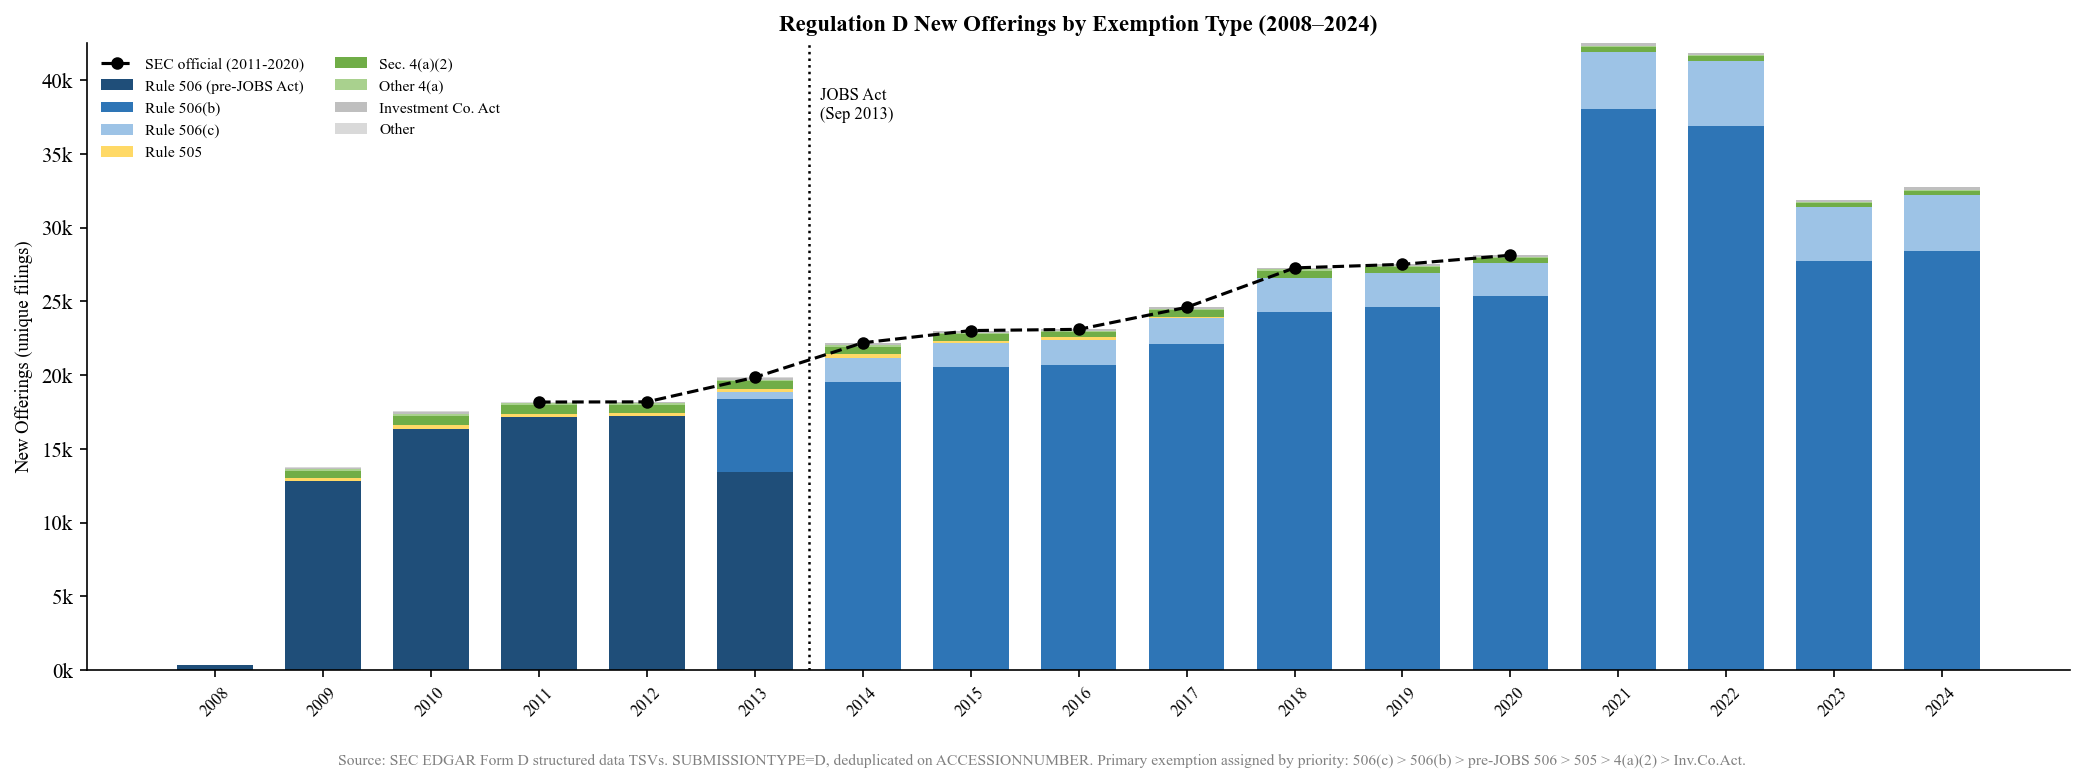

Saved.


In [6]:
COLORS = {
    'Rule 506 (pre-JOBS Act)': '#1f4e79',
    'Rule 506(b)':             '#2e75b6',
    'Rule 506(c)':             '#9dc3e6',
    'Rule 505':                '#ffd966',
    'Sec. 4(a)(2)':           '#70ad47',
    'Other 4(a)':             '#a9d18e',
    'Investment Co. Act':     '#bfbfbf',
    'Other':                   '#d9d9d9',
}
COL_ORDER = list(COLORS.keys())

# Map codes to display labels in pivot
display_pivot = pivot.drop(columns='TOTAL').copy()
display_pivot.columns = [ITEM_LABEL.get(c, 'Other') for c in display_pivot.columns]
display_pivot = display_pivot.T.groupby(level=0).sum().T  # merge duplicate labels

years = list(range(2008, 2025))
fig, ax = plt.subplots(figsize=(14, 5))

bottom = np.zeros(len(years))
for col in COL_ORDER:
    if col in display_pivot.columns:
        vals = [display_pivot.loc[y, col] if y in display_pivot.index else 0 for y in years]
        ax.bar(years, vals, bottom=bottom, color=COLORS[col], label=col, width=0.7)
        bottom += np.array(vals, dtype=float)

# SEC official overlay for validation years
ax.plot(
    sec_official.index,
    sec_official.values,
    'ko--', linewidth=1.5, markersize=5, label='SEC official (2011-2020)', zorder=5,
)

# JOBS Act marker
ax.axvline(2013.5, color='black', linestyle=':', linewidth=1.2)
ax.text(2013.6, ax.get_ylim()[1] * 0.88, 'JOBS Act\n(Sep 2013)', fontsize=8)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_title('Regulation D New Offerings by Exemption Type (2008\u20132024)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('New Offerings (unique filings)', fontsize=9)
ax.legend(fontsize=7.5, frameon=False, loc='upper left', ncol=2)
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], rotation=45, fontsize=8)

fig.text(0.5, -0.03,
         'Source: SEC EDGAR Form D structured data TSVs. '
         'SUBMISSIONTYPE=D, deduplicated on ACCESSIONNUMBER. '
         'Primary exemption assigned by priority: 506(c) > 506(b) > pre-JOBS 506 > 505 > 4(a)(2) > Inv.Co.Act.',
         ha='center', fontsize=7.5, color='gray')
plt.tight_layout()
plt.savefig('/Users/vwh7mb/areas/secreg/output/regd-plots/formd_regd.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved.')